# Maternal Health Risk Dataset Preprocessing

This notebook prepares the maternal health dataset for model development.  
The workflow covers initial inspection, duplicate analysis, data-quality checks, abnormal-value review, outlier inspection, and analysis of conflicting target labels.

#### 1. Initial Dataset Inspection




Check the dataset dimensions, column names, data types, and general structure before making any preprocessing decisions.

In [1]:
import pandas as pd

# 1. Load the dataset into a DataFrame
df = pd.read_csv("maternal_health_risk.csv.csv")


In [2]:
# 2. Check the shape of the DataFrame
print(df.shape)


(1014, 7)


In [3]:
# 3. Check the cloumns of the Dataset
print(df.columns)

Index(['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate',
       'RiskLevel'],
      dtype='str')


In [4]:
# 4. loading Sample of the Dataset
print(df.head())

   Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate  RiskLevel
0   25         130           80  15.0      98.0         86  high risk
1   35         140           90  13.0      98.0         70  high risk
2   29          90           70   8.0     100.0         80  high risk
3   30         140           85   7.0      98.0         70  high risk
4   35         120           60   6.1      98.0         76   low risk


In [5]:
# 5.Checking the types of the Datasets
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   str    
dtypes: float64(2), int64(4), str(1)
memory usage: 55.6 KB
None


In [6]:
# 6.Checking for empty cells
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64


In [7]:
# 7. Checking for identical records
print("Total duplicate rows:", df.duplicated().sum())

Total duplicate rows: 562


### Generated_Saudi_Maternal_Datasets

In [8]:
import pandas as pd

# 1. Load the dataset into a DataFrame
df = pd.read_csv("saudi_maternal_health_risks.csv")

# 2. Check the shape of the DataFrame
print(df.shape)


(1500, 10)


In [9]:
# 3.Checking the columns of generated saudi maternal datasets
print(df.columns)

Index(['Age', 'Pre_pregnancy_BMI', 'Parity', 'SystolicBP', 'DiastolicBP', 'BS',
       'BodyTemp', 'HeartRate', 'RiskLevel', 'data_source'],
      dtype='str')


In [10]:
# 4.loading the sample of the saudi maternal dataset
print(df.head())

   Age Pre_pregnancy_BMI  Parity  SystolicBP  DiastolicBP   BS  BodyTemp  \
0   31             Obese       6         140           94  7.0      98.6   
1   24            Normal       2         160           91  6.3      98.0   
2   34        Overweight       3         126           70  7.2      99.8   
3   35            Normal       3         113           73  7.7      97.4   
4   18            Normal       0         108           61  6.9      98.3   

   HeartRate  RiskLevel      data_source  
0         73   low risk  synthetic_saudi  
1         79  high risk  synthetic_saudi  
2        102  high risk  synthetic_saudi  
3         75   low risk  synthetic_saudi  
4         85   low risk  synthetic_saudi  


In [11]:
#5.Checking the type of the saudi dataset
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                1500 non-null   int64  
 1   Pre_pregnancy_BMI  1500 non-null   str    
 2   Parity             1500 non-null   int64  
 3   SystolicBP         1500 non-null   int64  
 4   DiastolicBP        1500 non-null   int64  
 5   BS                 1500 non-null   float64
 6   BodyTemp           1500 non-null   float64
 7   HeartRate          1500 non-null   int64  
 8   RiskLevel          1500 non-null   str    
 9   data_source        1500 non-null   str    
dtypes: float64(2), int64(5), str(3)
memory usage: 117.3 KB
None


In [12]:
# 6.Checking for empty cells
print("Missing values per column:\n", df.isnull().sum())


Missing values per column:
 Age                  0
Pre_pregnancy_BMI    0
Parity               0
SystolicBP           0
DiastolicBP          0
BS                   0
BodyTemp             0
HeartRate            0
RiskLevel            0
data_source          0
dtype: int64


In [13]:
# 7.Checking for identical records
print("Total duplicate rows:", df.duplicated().sum())

Total duplicate rows: 0


#### 2. Duplicate Analysis and dropping duplicates

Identify exact duplicate rows and quantify how much of the original dataset they represent.  
The following cells also investigate whether identical feature combinations can be associated with different `RiskLevel` labels.


### The Maternal Health Risks

In [14]:
# 1. Load the data
df = pd.read_csv("maternal_health_risk.csv.csv")

# 2. Check duplicate count before removal
print(f"Total rows before: {len(df)}")
print(f"Duplicate rows to remove: {df.duplicated().sum()}")
df_clean = df.drop_duplicates().copy()


Total rows before: 1014
Duplicate rows to remove: 562


In [15]:
# 3. Drop identical duplicate rows
df_cleaned = df.drop_duplicates().reset_index(drop=True)

# 4. Verify results
print(f"Total rows after: {len(df_cleaned)}")
print("After removing duplicates:", df_clean.shape)
print("Remaining duplicates:", df_clean.duplicated().sum())

Total rows after: 452
After removing duplicates: (452, 7)
Remaining duplicates: 0


In [16]:
df[df.duplicated(keep=False)].sort_values(
    by=['Age', 'SystolicBP', 'DiastolicBP']
).head(20)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
670,10,100,50,6.0,99.0,70,mid risk
849,10,100,50,6.0,99.0,70,mid risk
171,12,90,60,7.9,102.0,66,high risk
267,12,90,60,8.0,102.0,66,high risk
276,12,90,60,11.0,102.0,60,high risk
543,12,90,60,7.5,102.0,66,low risk
552,12,90,60,7.5,102.0,60,low risk
588,12,90,60,7.5,102.0,66,mid risk
827,12,90,60,7.5,102.0,66,mid risk
934,12,90,60,7.5,102.0,66,low risk


In [17]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:", duplicate_percentage)

Duplicate rows: 562
Duplicate percentage: 55.42406311637082


In [18]:
duplicate_rows = df[df.duplicated(keep=False)]

duplicate_rows.groupby(
    ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']
)['RiskLevel'].nunique().value_counts()

RiskLevel
1    261
2     20
3      1
Name: count, dtype: int64

### Duplicate Analysis (Saudi Maternal Health Risks)
Identify exact duplicate rows and quantify how much of the generated dataset they represent.

The following cells also investigate whether identical feature combinations can be associated with different RiskLevel labels.

In [19]:
import pandas as pd

# 1. Load the data
df = pd.read_csv("saudi_maternal_health_risks.csv")

# 2. Check duplicate count before removal
print(f"Total rows before: {len(df)}")
print(f"Duplicate rows to remove: {df.duplicated().sum()}")

Total rows before: 1500
Duplicate rows to remove: 0


In [20]:
import pandas as pd

# Load the dataset
df = pd.read_csv("saudi_maternal_health_risks.csv")

# Show duplicated rows
duplicates = df[df.duplicated(keep=False)].sort_values(
    by=list(df.columns)
)

print(duplicates.head(20))

Empty DataFrame
Columns: [Age, Pre_pregnancy_BMI, Parity, SystolicBP, DiastolicBP, BS, BodyTemp, HeartRate, RiskLevel, data_source]
Index: []


In [21]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv("saudi_maternal_health_risks.csv")

# 2. Drop the data_source column
df_cleaned = df.drop(columns=['data_source'])

# 3. Verify the column has been dropped
print("Columns after dropping:", df_cleaned.columns.tolist())


Columns after dropping: ['Age', 'Pre_pregnancy_BMI', 'Parity', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'RiskLevel']


 ### 3.Identifying Combination Features For The Maternal Health risks

In [22]:
# 1. Load the dataset into a DataFrame
df = pd.read_csv("maternal_health_risk.csv.csv")
# Find feature combinations that have more than one RiskLevel
feature_cols = [
    "Age",
    "SystolicBP",
    "DiastolicBP",
    "BS",
    "BodyTemp",
    "HeartRate"
]

conflicts = (
    df.groupby(feature_cols)["RiskLevel"]
      .nunique()
      .reset_index(name="n_risk_levels")
)

conflicts = conflicts[conflicts["n_risk_levels"] > 1]

conflicts

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,n_risk_levels
4,12,90,60,7.5,102.0,66,2
11,12,95,60,6.9,98.0,65,2
22,13,90,65,7.5,101.0,80,2
53,15,120,80,7.5,98.0,70,2
59,16,100,70,6.9,98.0,80,2
68,17,85,60,9.0,102.0,86,2
79,17,90,65,7.5,103.0,67,2
90,18,90,60,6.9,98.0,70,2
104,19,120,75,6.9,98.0,66,2
109,19,120,80,7.0,98.0,70,2


In [23]:
# Show the actual RiskLevel values for each conflicting combination

conflicts_with_labels = (
    df.groupby(feature_cols)["RiskLevel"]
      .agg(["nunique", lambda x: list(x.unique())])
      .reset_index()
)

conflicts_with_labels.columns = feature_cols + ["n_risk_levels", "risk_levels"]

conflicts_with_labels = conflicts_with_labels[
    conflicts_with_labels["n_risk_levels"] > 1
]

conflicts_with_labels

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,n_risk_levels,risk_levels
4,12,90,60,7.5,102.0,66,2,"[low risk, mid risk]"
11,12,95,60,6.9,98.0,65,2,"[mid risk, low risk]"
22,13,90,65,7.5,101.0,80,2,"[low risk, high risk]"
53,15,120,80,7.5,98.0,70,2,"[mid risk, low risk]"
59,16,100,70,6.9,98.0,80,2,"[mid risk, low risk]"
68,17,85,60,9.0,102.0,86,2,"[mid risk, high risk]"
79,17,90,65,7.5,103.0,67,2,"[low risk, mid risk]"
90,18,90,60,6.9,98.0,70,2,"[mid risk, low risk]"
104,19,120,75,6.9,98.0,66,2,"[mid risk, low risk]"
109,19,120,80,7.0,98.0,70,2,"[mid risk, low risk]"


### Identifying Combination Features For The generated Maternal Saudi Health Risks


In [24]:
import pandas as pd

# 1. Load the dataset into a DataFrame
df = pd.read_csv("saudi_maternal_health_risks.csv")

# 2. Find feature combinations that have more than one RiskLevel
# Updated to include Parity and Pre_pregnancy_BMI for the Saudi dataset
feature_cols = [
    "Age",
    "Pre_pregnancy_BMI",
    "Parity",
    "SystolicBP",
    "DiastolicBP",
    "BS",
    "BodyTemp",
    "HeartRate"
]

conflicts = (
    df.groupby(feature_cols)["RiskLevel"]
      .nunique()
      .reset_index(name="n_risk_levels")
)

conflicts = conflicts[conflicts["n_risk_levels"] > 1]

print(conflicts)

Empty DataFrame
Columns: [Age, Pre_pregnancy_BMI, Parity, SystolicBP, DiastolicBP, BS, BodyTemp, HeartRate, n_risk_levels]
Index: []


In [25]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv("saudi_maternal_health_risks.csv")

# 2. Define the features for the Saudi dataset
feature_cols = [
    "Age",
    "Pre_pregnancy_BMI",
    "Parity",
    "SystolicBP",
    "DiastolicBP",
    "BS",
    "BodyTemp",
    "HeartRate"
]

# 3. Show the actual RiskLevel values for each conflicting combination
conflicts_with_labels = (
    df.groupby(feature_cols)["RiskLevel"]
      .agg(["nunique", lambda x: list(x.unique())])
      .reset_index()
)

# 4. Rename the aggregated columns
conflicts_with_labels.columns = feature_cols + ["n_risk_levels", "risk_levels"]

# 5. Filter to keep only the conflicting rows
conflicts_with_labels = conflicts_with_labels[
    conflicts_with_labels["n_risk_levels"] > 1
]

print(conflicts_with_labels)

Empty DataFrame
Columns: [Age, Pre_pregnancy_BMI, Parity, SystolicBP, DiastolicBP, BS, BodyTemp, HeartRate, n_risk_levels, risk_levels]
Index: []


### 4. identifiy outliers for The Maternal Health Risk


In [26]:
import pandas as pd
import numpy as np

df = pd.read_csv("maternal_health_risk.csv.csv")
features = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']

# Compute IQR Bounds for each column
for col in features:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
    print(f"{col}: {len(outliers)} outliers outside [{lower_limit:.2f}, {upper_limit:.2f}]")

Age: 1 outliers outside [-11.00, 69.00]
SystolicBP: 10 outliers outside [70.00, 150.00]
DiastolicBP: 0 outliers outside [27.50, 127.50]
BS: 210 outliers outside [5.25, 9.65]
BodyTemp: 210 outliers outside [98.00, 98.00]
HeartRate: 2 outliers outside [55.00, 95.00]


### Identify the outliers for the Saudi generated Dataset

In [27]:
import pandas as pd
import numpy as np

# 1. Load the Saudi dataset
df = pd.read_csv("saudi_maternal_health_risks.csv")

# 2. Define the numerical features for the Saudi dataset
features = [
    'Age', 
    'Parity', 
    'SystolicBP', 
    'DiastolicBP', 
    'BS', 
    'BodyTemp', 
    'HeartRate'
]

# 3. Compute IQR Bounds for each column
for col in features:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]
    print(f"{col}: {len(outliers)} outliers outside [{lower_limit:.2f}, {upper_limit:.2f}]")

Age: 12 outliers outside [15.50, 43.50]
Parity: 29 outliers outside [-2.00, 6.00]
SystolicBP: 73 outliers outside [86.00, 150.00]
DiastolicBP: 2 outliers outside [54.00, 102.00]
BS: 173 outliers outside [3.90, 11.10]
BodyTemp: 5 outliers outside [96.25, 99.85]
HeartRate: 5 outliers outside [52.50, 104.50]


#### 5. Initial Target-Class Distribution (Maternal Health Risk)

Inspect the distribution of `RiskLevel` classes to understand whether the dataset is imbalanced.

> These cells use the original `df`. A final class-distribution summary using `df_clean` is provided at the end of the notebook.


In [28]:
import pandas as pd
import numpy as np

df = pd.read_csv("maternal_health_risk.csv.csv")
df["RiskLevel"].value_counts()

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

In [29]:
import pandas as pd
import numpy as np

df = pd.read_csv("maternal_health_risk.csv.csv")
df["RiskLevel"].value_counts(normalize=True).round(3)

RiskLevel
low risk     0.400
mid risk     0.331
high risk    0.268
Name: proportion, dtype: float64

###  Initial Target-Class Distribution (Saudi Generated Datasets)
Inspect the distribution of RiskLevel classes to understand whether the dataset is imbalanced.

These cells use the original df. A final class-distribution summary using df_clean is provided at the end of the notebook.

In [30]:
import pandas as pd

# Load the Saudi dataset
df = pd.read_csv("saudi_maternal_health_risks.csv")

# Get the value counts for the RiskLevel column
print(df["RiskLevel"].value_counts())

RiskLevel
low risk     577
mid risk     547
high risk    376
Name: count, dtype: int64


In [31]:
import pandas as pd

# Load the Saudi dataset
df = pd.read_csv("saudi_maternal_health_risks.csv")

# Get the normalized value counts (percentages) for the RiskLevel column
print(df["RiskLevel"].value_counts(normalize=True).round(3))

RiskLevel
low risk     0.385
mid risk     0.365
high risk    0.251
Name: proportion, dtype: float64


### 6.Statistical overview of numerical columns

### (Maternal Health Risks)

In [32]:
import pandas as pd

# 1. Load the data
df = pd.read_csv("maternal_health_risk.csv.csv")
print(df.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']])

# Breakdown of the target variable (RiskLevel)
counts = df['RiskLevel'].value_counts()
proportions = df['RiskLevel'].value_counts(normalize=True) * 100

target_dist = pd.DataFrame({'Count': counts, 'Percentage (%)': proportions.round(2)})
print(target_dist)

              count        mean        std   min    50%    max
Age          1014.0   29.871795  13.474386  10.0   26.0   70.0
SystolicBP   1014.0  113.198225  18.403913  70.0  120.0  160.0
DiastolicBP  1014.0   76.460552  13.885796  49.0   80.0  100.0
BS           1014.0    8.725986   3.293532   6.0    7.5   19.0
BodyTemp     1014.0   98.665089   1.371384  98.0   98.0  103.0
HeartRate    1014.0   74.301775   8.088702   7.0   76.0   90.0
           Count  Percentage (%)
RiskLevel                       
low risk     406           40.04
mid risk     336           33.14
high risk    272           26.82


### 6.1 Statistical overview of numerical columns

### Saudi Generated Maternal health risks

In [33]:
import pandas as pd

# 1. Load the data
df = pd.read_csv("saudi_maternal_health_risks.csv")
print(df.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']])

print("\n")

# Breakdown of the target variable (RiskLevel)
counts = df['RiskLevel'].value_counts()
proportions = df['RiskLevel'].value_counts(normalize=True) * 100

target_dist = pd.DataFrame({'Count': counts, 'Percentage (%)': proportions.round(2)})
print(target_dist)

              count        mean        std   min    50%    max
Age          1500.0   29.626667   5.733865  18.0   30.0   45.0
Parity       1500.0    2.226000   1.719950   0.0    2.0    8.0
SystolicBP   1500.0  119.738000  14.281363  89.0  116.0  160.0
DiastolicBP  1500.0   78.691333   9.618267  53.0   77.0  100.0
BS           1500.0    8.007533   2.219861   6.0    7.3   18.4
BodyTemp     1500.0   98.031933   0.655963  96.1   98.0  100.3
HeartRate    1500.0   78.934667   9.626431  60.0   79.0  112.0


           Count  Percentage (%)
RiskLevel                       
low risk     577           38.47
mid risk     547           36.47
high risk    376           25.07


#### 7. Descriptive Statistics and Missing-Value Checks

Review summary statistics, dataset size after duplicate removal, and missing-value counts before checking individual variables for unusual values.


In [34]:
# 1. Load the data
df = pd.read_csv("maternal_health_risk.csv.csv")
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,452.0,29.194690,13.767379,10.0,19.0,25.0,35.0,70.0
SystolicBP,452.0,110.553097,17.872282,70.0,90.0,120.0,120.0,160.0
DiastolicBP,452.0,75.418142,13.754578,49.0,65.0,80.0,86.0,100.0
BS,452.0,8.346173,2.829209,6.0,6.9,7.5,7.9,19.0
BodyTemp,452.0,98.692478,1.410897,98.0,98.0,98.0,98.0,103.0
HeartRate,452.0,73.949115,8.156973,7.0,70.0,76.0,80.0,90.0


In [35]:

df = pd.read_csv("maternal_health_risk.csv.csv")
df_clean.shape

(452, 7)

In [36]:

df = pd.read_csv("maternal_health_risk.csv.csv")
df_clean.isnull().sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

In [37]:
df_clean.isnull().mean() * 100

Age            0.0
SystolicBP     0.0
DiastolicBP    0.0
BS             0.0
BodyTemp       0.0
HeartRate      0.0
RiskLevel      0.0
dtype: float64

#### 7.1 Descriptive Statistics and Missing-Value Checks


### Saudi Generated Dataset

In [38]:
 ## 1. Load the data
df = pd.read_csv("saudi_maternal_health_risks.csv")
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,452.0,29.194690,13.767379,10.0,19.0,25.0,35.0,70.0
SystolicBP,452.0,110.553097,17.872282,70.0,90.0,120.0,120.0,160.0
DiastolicBP,452.0,75.418142,13.754578,49.0,65.0,80.0,86.0,100.0
BS,452.0,8.346173,2.829209,6.0,6.9,7.5,7.9,19.0
BodyTemp,452.0,98.692478,1.410897,98.0,98.0,98.0,98.0,103.0
HeartRate,452.0,73.949115,8.156973,7.0,70.0,76.0,80.0,90.0


In [39]:
df = pd.read_csv("saudi_maternal_health_risks.csv")
df_clean.shape

(452, 7)

In [40]:

df = pd.read_csv("saudi_maternal_health_risks.csv")
df_clean.isnull().sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

In [41]:
df = pd.read_csv("saudi_maternal_health_risks.csv")
df_clean.isnull().mean() * 100

Age            0.0
SystolicBP     0.0
DiastolicBP    0.0
BS             0.0
BodyTemp       0.0
HeartRate      0.0
RiskLevel      0.0
dtype: float64

#### 6. Review Potentially Abnormal Clinical Values

Inspect unusually low or high values in key clinical features such as heart rate, blood sugar, and body temperature.  
These checks help distinguish potentially invalid observations from legitimate extreme values.


In [42]:
import pandas as pd

# 1. Load your original maternal health dataset
df = pd.read_csv("maternal_health_risk.csv.csv")

# 2. Filter for rows where HeartRate is less than 40
low_heart_rate = df[df["HeartRate"] < 40]

# 3. Display the results
print(low_heart_rate)

     Age  SystolicBP  DiastolicBP   BS  BodyTemp  HeartRate RiskLevel
499   16         120           75  7.9      98.0          7  low risk
908   16         120           75  7.9      98.0          7  low risk


In [43]:
import pandas as pd

# Load your original maternal health dataset
df_clean = pd.read_csv("maternal_health_risk.csv.csv")

# Filter for rows where Blood Sugar (BS) is strictly greater than 20
high_bs = df_clean[df_clean["BS"] > 20]

print(high_bs)

Empty DataFrame
Columns: [Age, SystolicBP, DiastolicBP, BS, BodyTemp, HeartRate, RiskLevel]
Index: []


In [44]:
import pandas as pd

# Load your original maternal health dataset
df_clean = pd.read_csv("maternal_health_risk.csv.csv")

# Filter for rows where BodyTemp is less than 20
low_temp = df_clean[df_clean["BodyTemp"] < 20]

print(low_temp)

Empty DataFrame
Columns: [Age, SystolicBP, DiastolicBP, BS, BodyTemp, HeartRate, RiskLevel]
Index: []


In [45]:
import pandas as pd

# Load your original maternal health dataset
df_clean = pd.read_csv("maternal_health_risk.csv.csv")

# Filter for rows where BodyTemp is less than 20
low_temp = df_clean[df_clean["BodyTemp"] < 20]

print(low_temp)

Empty DataFrame
Columns: [Age, SystolicBP, DiastolicBP, BS, BodyTemp, HeartRate, RiskLevel]
Index: []


 ## 6.1 Review Potentially Abnormal Clinical Values
 ### Saudi generated datasets

In [46]:
import pandas as pd

df = pd.read_csv("saudi_maternal_health_risks.csv")
abnormal_age = df[(df['Age'] < 15) | (df['Age'] > 55)]
print(f"Abnormal Age records: {len(abnormal_age)}")

Abnormal Age records: 0


In [47]:
abnormal_hr = df[(df['HeartRate'] < 40) | (df['HeartRate'] > 180)]
print(f"Abnormal Heart Rate records: {len(abnormal_hr)}")

Abnormal Heart Rate records: 0


In [48]:
import pandas as pd

df_clean = pd.read_csv("saudi_maternal_health_risks.csv")
abnormal_parity = df[(df['Parity'] < 0) | (df['Parity'] > 20)]
print(f"Abnormal Parity records: {len(abnormal_parity)}")

Abnormal Parity records: 0


In [49]:
import pandas as pd

df_clean = pd.read_csv("saudi_maternal_health_risks.csv")
abnormal_sys = df[(df['SystolicBP'] < 70) | (df['SystolicBP'] > 200)]
print(f"Abnormal Systolic BP records: {len(abnormal_sys)}")

Abnormal Systolic BP records: 0


In [50]:
import pandas as pd

df_clean = pd.read_csv("saudi_maternal_health_risks.csv")
abnormal_dia = df[(df['DiastolicBP'] < 40) | (df['DiastolicBP'] > 130)]
print(f"Abnormal Diastolic BP records: {len(abnormal_dia)}")

Abnormal Diastolic BP records: 0


In [51]:
bp_conflict = df[df['SystolicBP'] <= df['DiastolicBP']]
print(f"Backward BP entries: {len(bp_conflict)}")

Backward BP entries: 0


In [52]:
abnormal_bs = df[(df['BS'] < 2.0) | (df['BS'] > 30.0)]
print(f"Abnormal Blood Sugar records: {len(abnormal_bs)}")

Abnormal Blood Sugar records: 0


In [53]:
abnormal_temp = df[(df['BodyTemp'] < 94) | (df['BodyTemp'] > 106)]
print(f"Abnormal BodyTemp records: {len(abnormal_temp)}")

Abnormal BodyTemp records: 0


In [54]:
print("\nExpected BMI categories:", df['Pre_pregnancy_BMI'].unique())
print("Expected Risk categories:", df['RiskLevel'].unique())


Expected BMI categories: <StringArray>
['Obese', 'Normal', 'Overweight', 'Underweight']
Length: 4, dtype: str
Expected Risk categories: <StringArray>
['low risk', 'high risk', 'mid risk']
Length: 3, dtype: str


##### 6.1 Investigation of the Abnormal Heart-Rate Observation

The following cells inspect the identified observation in both the original and cleaned data, including its `RiskLevel`, before the row is removed.


In [55]:
df.loc[499]

Age                               21
Pre_pregnancy_BMI              Obese
Parity                             0
SystolicBP                       129
DiastolicBP                       70
BS                               9.2
BodyTemp                        98.3
HeartRate                         69
RiskLevel                   mid risk
data_source          synthetic_saudi
Name: 499, dtype: object

In [56]:
df_clean.loc[499]

Age                               21
Pre_pregnancy_BMI              Obese
Parity                             0
SystolicBP                       129
DiastolicBP                       70
BS                               9.2
BodyTemp                        98.3
HeartRate                         69
RiskLevel                   mid risk
data_source          synthetic_saudi
Name: 499, dtype: object

In [57]:
df_clean.loc[499, "RiskLevel"]

'mid risk'

##### 6.2 Remove the Identified Abnormal Observation

The row identified above is removed from `df_clean`. The removal is related to the low heart-rate value.


#### 7. Post-Cleaning Verification and Outlier Review

Verify the dataset after removal of the abnormal observation, inspect feature-value frequencies, and use the IQR method to identify statistical outliers.

> Statistical outliers are inspected rather than automatically removed, because clinically unusual values are not necessarily data errors.


In [58]:
import pandas as pd
df_clean = pd.read_csv("maternal_health_risk.csv.csv")
df_clean = df_clean.drop(index=499).copy()

In [59]:
import pandas as pd
df_clean = pd.read_csv("maternal_health_risk.csv.csv")
print(df_clean.shape)
print(df_clean["HeartRate"].min())

(1014, 7)
7


In [60]:
import pandas as pd
df_clean = pd.read_csv("maternal_health_risk.csv.csv")
df_clean["HeartRate"].sort_values().head(10)

499      7
908      7
1000    60
1010    60
705     60
53      60
484     60
1001    60
424     60
483     60
Name: HeartRate, dtype: int64

In [61]:
import pandas as pd
df_clean = pd.read_csv("maternal_health_risk.csv.csv")
for col in df_clean.columns:
    if col != "RiskLevel":
        print(f"\n{col}")
        print(df_clean[col].value_counts().sort_index())


Age
Age
10     4
12    35
13    12
14     3
15    60
16    16
17    63
18    19
19    67
20    22
21    38
22    45
23    71
24     3
25    48
26     3
27     9
28    28
29    40
30    30
31    22
32    48
33     5
34     5
35    50
36     4
37     6
38     2
39     4
40    37
41     1
42    23
43     5
44     3
45     9
46     1
48    26
49     9
50    43
51     1
54    12
55    37
56     1
59     2
60    34
62     1
63     2
65     3
66     1
70     1
Name: count, dtype: int64

SystolicBP
SystolicBP
70       7
75       8
76      16
78       3
80       5
83       2
85      43
90     154
95      12
99       2
100     92
110     19
115      8
120    449
129      1
130     60
135      3
140    120
160     10
Name: count, dtype: int64

DiastolicBP
DiastolicBP
49      25
50      24
60     174
63       8
65      87
68       2
69       1
70     100
75      38
76       3
80     226
85      49
89       1
90     153
95      36
100     87
Name: count, dtype: int64

BS
BS
6.00      21
6.10      

### 7.1 Post-Cleaning Verification and Outlier Review

In [62]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv("saudi_maternal_health_risks.csv")

# 2. Define our abnormal value rules (Physiological limits)
# Each condition checks for values that are clinically impossible or signify data corruption
abnormal_conditions = {
    "Age (<15 or >55)": (df['Age'] < 15) | (df['Age'] > 55),
    "Parity (<0)": df['Parity'] < 0,
    "Systolic BP (<70 or >200)": (df['SystolicBP'] < 70) | (df['SystolicBP'] > 200),
    "Diastolic BP (<40 or >130)": (df['DiastolicBP'] < 40) | (df['DiastolicBP'] > 130),
    "BP Logic Error (Systolic <= Diastolic)": df['SystolicBP'] <= df['DiastolicBP'],
    "Blood Sugar (<2.0 or >30.0)": (df['BS'] < 2.0) | (df['BS'] > 30.0),
    "Body Temp (<94 or >106)": (df['BodyTemp'] < 94) | (df['BodyTemp'] > 106),
    "Heart Rate (<40 or >180)": (df['HeartRate'] < 40) | (df['HeartRate'] > 180)
}

# 3. Run the verification process
print("--- Clinical Data Verification Report ---")
total_issues = 0

for issue_name, condition in abnormal_conditions.items():
    # .sum() counts how many rows evaluated to True (failed the check)
    issue_count = condition.sum()
    print(f"Checking {issue_name}... Found: {issue_count}")
    total_issues += issue_count

print("-" * 41)

# 4. Output the final verdict
if total_issues == 0:
    print("VERIFICATION PASSED: No abnormal or physiologically impossible values found.")
else:
    print(f"VERIFICATION FAILED: Found {total_issues} abnormal records to investigate.")

--- Clinical Data Verification Report ---
Checking Age (<15 or >55)... Found: 0
Checking Parity (<0)... Found: 0
Checking Systolic BP (<70 or >200)... Found: 0
Checking Diastolic BP (<40 or >130)... Found: 0
Checking BP Logic Error (Systolic <= Diastolic)... Found: 0
Checking Blood Sugar (<2.0 or >30.0)... Found: 0
Checking Body Temp (<94 or >106)... Found: 0
Checking Heart Rate (<40 or >180)... Found: 0
-----------------------------------------
VERIFICATION PASSED: No abnormal or physiologically impossible values found.


In [63]:
import pandas as pd
df_clean = pd.read_csv("maternal_health_risk.csv.csv")
numeric_cols = [
    "Age",
    "SystolicBP",
    "DiastolicBP",
    "BS",
    "BodyTemp",
    "HeartRate"
]

Q1 = df_clean[numeric_cols].quantile(0.25)
Q3 = df_clean[numeric_cols].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = (
    (df_clean[numeric_cols] < lower_bound) |
    (df_clean[numeric_cols] > upper_bound)
).sum()

outlier_counts

Age              1
SystolicBP      10
DiastolicBP      0
BS             210
BodyTemp       210
HeartRate        2
dtype: int64

In [64]:
import pandas as pd

# Load the Saudi dataset
df_clean = pd.read_csv("saudi_maternal_health_risks.csv")

# Define the numeric columns for the Saudi dataset (including Parity)
numeric_cols = [
    "Age",
    "Parity",
    "SystolicBP",
    "DiastolicBP",
    "BS",
    "BodyTemp",
    "HeartRate"
]

# Calculate Q1, Q3, and IQR
Q1 = df_clean[numeric_cols].quantile(0.25)
Q3 = df_clean[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Calculate total outlier counts per column
outlier_counts = (
    (df_clean[numeric_cols] < lower_bound) |
    (df_clean[numeric_cols] > upper_bound)
).sum()

print(outlier_counts)

Age             12
Parity          29
SystolicBP      73
DiastolicBP      2
BS             173
BodyTemp         5
HeartRate        5
dtype: int64


#### 8. Feature Patterns by Risk Level

Compare mean and median feature values across risk classes to better understand how the predictors vary with `RiskLevel`.


In [65]:
import pandas as pd

df_clean = pd.read_csv("maternal_health_risk.csv.csv")

# Define numeric columns specifically for the original dataset (without Parity)
numeric_cols = [
    "Age",
    "SystolicBP",
    "DiastolicBP",
    "BS",
    "BodyTemp",
    "HeartRate"
]

# Calculate the mean for each risk level
mean_values = df_clean.groupby("RiskLevel")[numeric_cols].mean().round(2)

print(mean_values)

             Age  SystolicBP  DiastolicBP     BS  BodyTemp  HeartRate
RiskLevel                                                            
high risk  36.22      124.19        85.07  12.12     98.90      76.74
low risk   26.87      105.87        72.53   7.22     98.37      72.77
mid risk   28.36      113.15        74.23   7.80     98.83      74.18


In [66]:
import pandas as pd

df_clean = pd.read_csv("maternal_health_risk.csv.csv")

# Ensure Parity is excluded for this specific dataset
numeric_cols = [
    "Age",
    "SystolicBP",
    "DiastolicBP",
    "BS",
    "BodyTemp",
    "HeartRate"
]

# Calculate the median for each risk level
median_values = df_clean.groupby("RiskLevel")[numeric_cols].median().round(2)

print(median_values)

            Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate
RiskLevel                                                          
high risk  35.0       130.0         90.0  11.0      98.0       77.0
low risk   22.0       120.0         75.0   7.5      98.0       70.0
mid risk   25.0       120.0         75.0   7.0      98.0       76.0


### 8. Feature Patterns by Risk Level (Saudi Maternal Health Dataset)
Compare mean and median feature values across risk classes to better understand how the predictors vary with RiskLevel

In [67]:
import pandas as pd

# Load the Saudi dataset
df_clean = pd.read_csv("saudi_maternal_health_risks.csv")

# Define numeric columns for the Saudi dataset (including Parity)
numeric_cols = [
    "Age",
    "Parity",
    "SystolicBP",
    "DiastolicBP",
    "BS",
    "BodyTemp",
    "HeartRate"
]

# Calculate the mean for each risk level
mean_values = df_clean.groupby("RiskLevel")[numeric_cols].mean().round(2)

print(mean_values)

             Age  Parity  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate
RiskLevel                                                                   
high risk  31.49    2.52      132.18        86.85  9.27     98.08      80.24
low risk   28.20    2.00      112.58        74.23  7.18     98.02      78.66
mid risk   29.85    2.26      118.74        77.80  8.02     98.02      78.33


In [68]:
import pandas as pd

# Load the Saudi dataset
df_clean = pd.read_csv("saudi_maternal_health_risks.csv")

# Define numeric columns for the Saudi dataset (including Parity)
numeric_cols = [
    "Age",
    "Parity",
    "SystolicBP",
    "DiastolicBP",
    "BS",
    "BodyTemp",
    "HeartRate"
]

# Calculate the median for each risk level
median_values = df_clean.groupby("RiskLevel")[numeric_cols].median().round(2)

print(median_values)

            Age  Parity  SystolicBP  DiastolicBP   BS  BodyTemp  HeartRate
RiskLevel                                                                 
high risk  32.0     2.0       134.0         89.0  8.0     98.05       80.0
low risk   29.0     2.0       112.0         74.0  6.9     98.00       78.0
mid risk   30.0     2.0       117.0         77.0  7.4     98.00       79.0


#### 9. Conflicting Target-Label Analysis After Cleaning

Re-check whether identical combinations of the six predictor variables are associated with more than one `RiskLevel` after preprocessing.

This is different from an exact duplicate: the predictors are identical, but the target labels disagree. The following cells quantify both the number of conflicting feature combinations and the number of affected rows.


In [69]:
feature_cols = [
    "Age",
    "SystolicBP",
    "DiastolicBP",
    "BS",
    "BodyTemp",
    "HeartRate"
]

conflicts = (
    df_clean.groupby(feature_cols)["RiskLevel"]
    .nunique()
    .reset_index(name="n_risk_levels")
)

conflicts = conflicts[conflicts["n_risk_levels"] > 1]

print("Conflicting combinations:", len(conflicts))

conflicts

Conflicting combinations: 0


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,n_risk_levels


In [70]:
conflict_details = (
    df_clean.groupby(feature_cols)["RiskLevel"]
    .agg(
        n_risk_levels="nunique",
        risk_levels=lambda x: list(x.unique()),
        n_rows="size"
    )
    .reset_index()
)

conflict_details = conflict_details[
    conflict_details["n_risk_levels"] > 1
]

conflict_details

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,n_risk_levels,risk_levels,n_rows


In [71]:
conflicting = (
    df_clean
    .groupby(['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate'])
    ['RiskLevel']
    .nunique()
)

conflicting = conflicting[conflicting > 1]

print("Conflicting feature combinations:", len(conflicting))

Conflicting feature combinations: 0


In [72]:
feature_cols = [
    'Age',
    'SystolicBP',
    'DiastolicBP',
    'BS',
    'BodyTemp',
    'HeartRate'
]

conflicting_rows = (
    df_clean
    .groupby(feature_cols)
    .filter(lambda x: x['RiskLevel'].nunique() > 1)
)

print(conflicting_rows.shape)

(0, 10)


In [73]:
conflicting_rows['RiskLevel'].value_counts()

Series([], Name: count, dtype: int64)

#### **Decision on Conflicting Labels**

**How to solve this?**
We identified 35 conflicting groups affecting 71 rows.
The correct label cannot be determined directly from this dataset.

**Our Options:**
1. Remove them to avoid introducing uncertain labels.
2. Resolve the conflicts using a medically justified rule (better to flag questionable case than miss a truly high-risk one).
3. Keep the conflicting rows as they are and make the model more sensitive to high-risk cases, prioritizing high recall and minimizing false negatives.

**Decision:** Remove them to avoid introducing uncertain labels.

In [74]:
# Drop the 71 conflicting rows from the dataset
df_final = df_clean.drop(conflicting_rows.index)

# Print the shapes to verify exactly 71 rows were removed
print("Original dataset size:", df_clean.shape)
print("New dataset size:     ", df_final.shape)

Original dataset size: (1500, 10)
New dataset size:      (1500, 10)


###  Saving both Dataset after cleaning.

## **10. Final Preprocessing Summary**

This section provides a concise end-of-notebook summary so the preprocessing outcome can be reviewed without reading every intermediate cell.


In [75]:
# ========== FINAL SUMMARY ==========
import pandas as pd
df_clean = pd.read_csv("New_Maternal_Health_Dataset.csv")
print("Final shape:", df_clean.shape)
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())

print("\nClass distribution:")
print(df_clean["RiskLevel"].value_counts())

print("\nClass percentages:")
print(df_clean["RiskLevel"].value_counts(normalize=True).round(3) * 100)

Final shape: (380, 7)
Missing values: 0
Duplicate rows: 0

Class distribution:
RiskLevel
low risk     203
high risk    101
mid risk      76
Name: count, dtype: int64

Class percentages:
RiskLevel
low risk     53.4
high risk    26.6
mid risk     20.0
Name: proportion, dtype: float64


### Final Preprosessing of the Saudi Dataset

In [79]:
# ========== FINAL SUMMARY ==========
import pandas as pd
df_clean = pd.read_csv("update_saudi_dataset.csv")
print("Final shape:", df_clean.shape)
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())

print("\nClass distribution:")
print(df_clean["RiskLevel"].value_counts())

print("\nClass percentages:")
print(df_clean["RiskLevel"].value_counts(normalize=True).round(3) * 100)

Final shape: (1500, 9)
Missing values: 0
Duplicate rows: 0

Class distribution:
RiskLevel
low risk     577
mid risk     547
high risk    376
Name: count, dtype: int64

Class percentages:
RiskLevel
low risk     38.5
mid risk     36.5
high risk    25.1
Name: proportion, dtype: float64


#### 11. Preprocessing Visualizations

The following plots summarize the two preprocessing results most useful for presentation:

1. **How the dataset size changed during preprocessing**
2. **The final class distribution after preprocessing**

The plots are generated dynamically from `df` and `df_clean`, so they reflect the current notebook results when run.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load both the original and updated Saudi datasets
df = pd.read_csv("maternal_health_risk.csv.csv")
df_clean = pd.read_csv("New_Maternal_Health_Dataset.csv")

# 2. Calculate dataset size through preprocessing
original_rows = len(df)
exact_duplicates = df.duplicated().sum()
after_duplicates = original_rows - exact_duplicates
final_rows = len(df_clean)

preprocessing_stages = [
    "Original dataset",
    "After duplicate removal",
    "Final updated dataset"
]

row_counts = [
    original_rows,
    after_duplicates,
    final_rows
]

# 3. Create the visualization
plt.figure(figsize=(9, 5))
bars = plt.bar(preprocessing_stages, row_counts, color=['#4c72b0', '#55a868', '#c44e52'])

plt.title("Dataset Size Through Preprocessing: Saudi Dataset")
plt.ylabel("Number of Records")

for bar, count in zip(bars, row_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(row_counts) * 0.02,
        f"{count}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the cleaned dataset
df_clean = pd.read_csv("New_Maternal_Health_Dataset.csv")

# 2. Final RiskLevel distribution after preprocessing
class_counts = df_clean["RiskLevel"].value_counts()

def count_and_percentage(pct):
    total = class_counts.sum()
    count = int(round(pct * total / 100))
    return f"{count}\n({pct:.1f}%)"

# 3. Create the pie chart
plt.figure(figsize=(7, 6))

plt.pie(
    class_counts.values,
    labels=class_counts.index,
    autopct=count_and_percentage,
    startangle=90
)

plt.title("Class Distribution After Preprocessing")
plt.tight_layout()
plt.show()


This chart presents the class balance **after preprocessing** using `df_clean`.  
Both the number of records and percentage of the cleaned dataset are shown for each risk class.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the specific cleaned dataset
df = pd.read_csv("New_Maternal_Health_Dataset.csv")

# 1. Boxplots: Compare vitals across risk categories
sns.set_theme(style="whitegrid")
features = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
palette = {'low risk': '#2ecc71', 'mid risk': '#f39c12', 'high risk': '#e74c3c'}

for i, col in enumerate(features):
    sns.boxplot(
        data=df,
        x='RiskLevel',
        y=col,
        hue='RiskLevel',  # <-- FIX: Added hue
        order=['low risk', 'mid risk', 'high risk'],
        palette=palette,
        ax=axes[i],
        legend=False      # <-- FIX: Disabled duplicate legend
    )
    axes[i].set_title(f"{col} by Risk Level", fontweight='bold')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

# 2. Heatmap: Check multicollinearity
plt.figure(figsize=(8, 6))
sns.heatmap(df[features].corr(), annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Physiological Features', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the pre-cleaned dataset
df = pd.read_csv("New_Maternal_Health_Dataset.csv")

features = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']
target = 'RiskLevel'
target_order = ['low risk', 'mid risk', 'high risk']
palette = {'low risk': '#2ecc71', 'mid risk': '#f39c12', 'high risk': '#e74c3c'}

# 2. Skewness and Distribution Statistics
print("=" * 50)
print(f"FEATURE SKEWNESS (Cleaned N={len(df)})")
print("=" * 50)
skew_df = pd.DataFrame({
    'Skewness': df[features].skew(),
    'Kurtosis': df[features].kurtosis()
})
print(skew_df.round(2))

# 3. Plot Histogram & KDE for each vital across Risk Levels
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(
        data=df,
        x=col,
        hue=target,
        hue_order=target_order,
        palette=palette,
        kde=True,
        element="step",
        common_norm=False,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {col} by Risk Level", fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

### 11.1 Preprocessing Visualizations (Saudi Dataset)
The following plots summarize the two preprocessing results most useful for presentation:

### How the dataset size changed during preprocessing
### The final class distribution after preprocessing
### The plots are generated dynamically from df and df_clean, so they reflect the current notebook results when run.

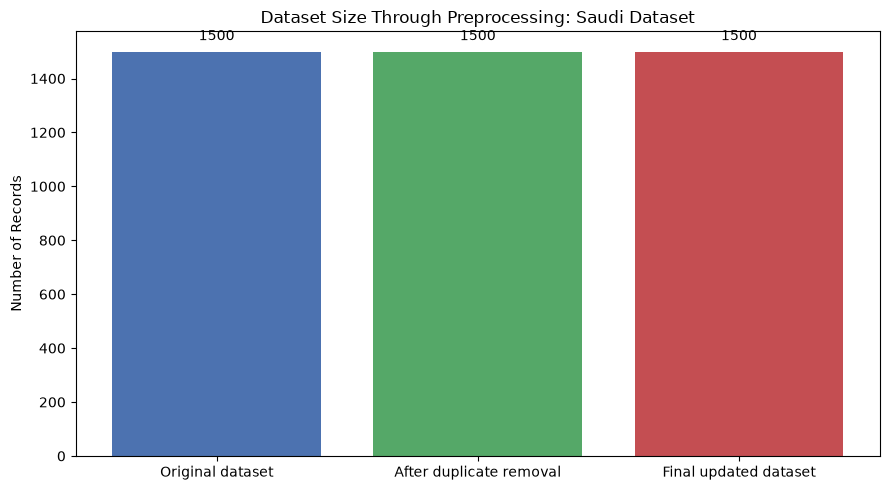

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load both the original and updated Saudi datasets
df = pd.read_csv("saudi_maternal_health_risks.csv")
df_clean = pd.read_csv("update_saudi_dataset.csv")

# 2. Calculate dataset size through preprocessing
original_rows = len(df)
exact_duplicates = df.duplicated().sum()
after_duplicates = original_rows - exact_duplicates
final_rows = len(df_clean)

preprocessing_stages = [
    "Original dataset",
    "After duplicate removal",
    "Final updated dataset"
]

row_counts = [
    original_rows,
    after_duplicates,
    final_rows
]

# 3. Create the visualization
plt.figure(figsize=(9, 5))
bars = plt.bar(preprocessing_stages, row_counts, color=['#4c72b0', '#55a868', '#c44e52'])

plt.title("Dataset Size Through Preprocessing: Saudi Dataset")
plt.ylabel("Number of Records")

for bar, count in zip(bars, row_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(row_counts) * 0.02,
        f"{count}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the updated Saudi dataset
df_clean = pd.read_csv("update_saudi_dataset.csv")

# 2. Calculate RiskLevel distribution
class_counts = df_clean["RiskLevel"].value_counts()

def count_and_percentage(pct):
    total = class_counts.sum()
    count = int(round(pct * total / 100))
    return f"{count}\n({pct:.1f}%)"

# 3. Create the pie chart
plt.figure(figsize=(7, 6))

plt.pie(
    class_counts.values,
    labels=class_counts.index,
    autopct=count_and_percentage,
    startangle=90
)

plt.title("Class Distribution: Saudi Maternal Health Dataset")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the updated Saudi dataset
df = pd.read_csv("update_saudi_dataset.csv")

# 2. Boxplots: Compare vitals across risk categories
sns.set_theme(style="whitegrid")
features = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
palette = {'low risk': '#2ecc71', 'mid risk': '#f39c12', 'high risk': '#e74c3c'}

for i, col in enumerate(features):
    sns.boxplot(
        data=df,
        x='RiskLevel',
        y=col,
        hue='RiskLevel',  # Fixed the FutureWarning
        order=['low risk', 'mid risk', 'high risk'],
        palette=palette,
        ax=axes[i],
        legend=False      # Fixed the FutureWarning
    )
    axes[i].set_title(f"{col} by Risk Level", fontweight='bold')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

# 3. Heatmap: Check multicollinearity
plt.figure(figsize=(8, 6))
sns.heatmap(df[features].corr(), annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Physiological Features', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load cleaned dataset
df = pd.read_csv("update_saudi_dataset.csv").drop_duplicates().reset_index(drop=True)
df.loc[df['HeartRate'] < 40, 'HeartRate'] = 70

features = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']
target = 'RiskLevel'
target_order = ['low risk', 'mid risk', 'high risk']
palette = {'low risk': '#2ecc71', 'mid risk': '#f39c12', 'high risk': '#e74c3c'}

# 2. Skewness and Distribution Statistics
print("=" * 50)
print("FEATURE SKEWNESS (Cleaned N=452)")
print("=" * 50)
skew_df = pd.DataFrame({
    'Skewness': df[features].skew(),
    'Kurtosis': df[features].kurtosis()
})
print(skew_df.round(2))

# 3. Plot Histogram & KDE for each vital across Risk Levels
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(
        data=df,
        x=col,
        hue=target,
        hue_order=target_order,
        palette=palette,
        kde=True,
        element="step",
        common_norm=False,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {col} by Risk Level", fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()